 # **Telecom X - Análise de Evasão de Clientes.(Parte 2)**


 Nesse desafio sou um Analista de Machine Learning Júnior e minha nova missão é desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços.

 A empresa quer antecipar o problema da evasão, e cabe a você construir um pipeline robusto para essa etapa inicial de modelagem.

####Objetivos do Desafio:
- Preparar os dados para a modelagem (tratamento, encoding, normalização);
- Realizar análise de correlação e seleção de variáveis;
- Treinar dois ou mais modelos de classificação;
- Avaliar o desempenho dos modelos com métricas;
- Interpretar os resultados, incluindo a importância das variáveis;
- Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

####O que você mais pratiquei:
- Pré-processamento de dados para Machine Learning;
- Construção e avaliação de modelos preditivos;
- Interpretação dos resultados e entrega de insights;
- Comunicação técnica com foco estratégico.


## **Extração do Arquivo Tratado.**

CarregueI o arquivo CSV que contém os dados tratados anteriormente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from datetime import datetime
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('/content/dados_tratados.csv')
df.head()

,id_cliente,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


###**Remoção de Colunas Irrelevantes**

Eliminei colunas que não trazem valor para a análise ou para os modelos preditivos, como identificadores únicos (por exemplo, o ID do cliente). Essas colunas não ajudam na previsão da evasão e podem até prejudicar o desempenho dos modelos.

In [3]:
df.drop(["id_cliente"], axis=1, inplace=True)
df.head()

,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0,Female,0,1,1,9,1,0.0,DSL,No,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1.0,DSL,No,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0.0,Fiber optic,No,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0.0,Fiber optic,No,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0.0,Fiber optic,No,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [4]:
df.shape

(7032, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cancelamento          7032 non-null   int64  
 1   genero                7032 non-null   object 
 2   idoso                 7032 non-null   int64  
 3   possui_parceiro       7032 non-null   int64  
 4   possui_dependentes    7032 non-null   int64  
 5   tempo_contrato_meses  7032 non-null   int64  
 6   servico_telefone      7032 non-null   int64  
 7   multiplas_linhas      6352 non-null   float64
 8   tipo_internet         7032 non-null   object 
 9   seguranca_online      7032 non-null   object 
 10  backup_online         7032 non-null   object 
 11  protecao_dispositivo  5512 non-null   float64
 12  suporte_tecnico       5512 non-null   float64
 13  streaming_tv          5512 non-null   float64
 14  streaming_filmes      5512 non-null   float64
 15  tipo_contrato        

###**Encoding.**

Transformei as variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning. Utilizei um método de codificação adequado, como o one-hot encoding.

In [6]:
X = df.drop('cancelamento', axis=1)
y = df['cancelamento']

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'),
     ['genero', 'tipo_internet', 'seguranca_online',
      'backup_online', 'tipo_contrato', 'metodo_pagamento']),
    remainder='passthrough'
)

X = one_hot.fit_transform(X)

In [7]:
X = pd.DataFrame(
    X,
    columns=one_hot.get_feature_names_out()
)

columns_to_impute = [
    'remainder__multiplas_linhas',
    'remainder__protecao_dispositivo',
    'remainder__suporte_tecnico',
    'remainder__streaming_tv',
    'remainder__streaming_filmes'
]

imputer = SimpleImputer(strategy='mean')

X[columns_to_impute] = imputer.fit_transform(X[columns_to_impute])

X.head()

,onehotencoder__genero_Male,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__tipo_internet_No,onehotencoder__seguranca_online_No,onehotencoder__seguranca_online_No internet service,onehotencoder__seguranca_online_Yes,onehotencoder__backup_online_No,onehotencoder__backup_online_No internet service,onehotencoder__backup_online_Yes,...,remainder__servico_telefone,remainder__multiplas_linhas,remainder__protecao_dispositivo,remainder__suporte_tecnico,remainder__streaming_tv,remainder__streaming_filmes,remainder__fatura_digital,remainder__valor_mensal,remainder__total_cobrado,remainder__contas_diarias
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.186667
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,1.996667
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.463333
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.796667


In [8]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   onehotencoder__genero_Male                                 7032 non-null   float64
 1   onehotencoder__tipo_internet_DSL                           7032 non-null   float64
 2   onehotencoder__tipo_internet_Fiber optic                   7032 non-null   float64
 3   onehotencoder__tipo_internet_No                            7032 non-null   float64
 4   onehotencoder__seguranca_online_No                         7032 non-null   float64
 5   onehotencoder__seguranca_online_No internet service        7032 non-null   float64
 6   onehotencoder__seguranca_online_Yes                        7032 non-null   float64
 7   onehotencoder__backup_online_No                            7032 non-null   float64
 8   onehoten

###**Verificação da Proporção de Evasão**

Calculei a proporção de clientes que evadiram em relação aos que permaneceram ativos. Avaliei se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

In [9]:
y.value_counts(normalize=True)

,proportion
cancelamento,
0,0.734215
1,0.265785


###**Balanceamento de Classes.**

Apliquei técnicas de balanceamento como undersampling ou oversampling. Em situações de forte desbalanceamento, ferramentas como o SMOTE podem ser úteis para gerar exemplos sintéticos da classe minoritária.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=42)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
X_treino, y_treino = smote.fit_resample(X_treino, y_treino)

In [12]:
y_treino.value_counts(normalize=True)

,proportion
cancelamento,
0,0.5
1,0.5


###**Normalização ou Padronização.**

Avaliei a necessidade de normalizar ou padronizar os dados, conforme os modelos que serão aplicados.

Obs: Modelos baseados em distância, como KNN, SVM, Regressão Logística e Redes Neurais, requerem esse pré-processamento.
Já modelos baseados em árvore, como Decision Tree, Random Forest e XGBoost, não são sensíveis à escala dos dados.

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

X_treino = scaler.fit_transform(X_treino)
X_teste = scaler.transform(X_teste)

##**Correlação e Seleção de Variáveis.**

###**Análise de Correlação.**


VisualizeI a matriz de correlação para identificar relações entre variáveis numéricas. ObserveI especialmente quais variáveis apresentam maior correlação com a evasão, pois elas podem ser fortes candidatas para o modelo preditivo.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

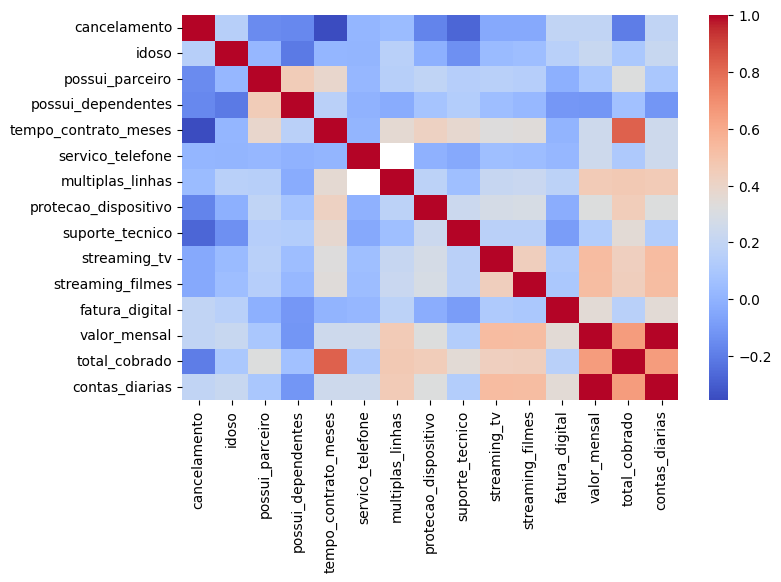

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap='coolwarm')
plt.show()

In [17]:
df.select_dtypes(include=['int64','float64']).corr()['cancelamento'].sort_values(ascending=False)

,cancelamento
cancelamento,1.000000
contas_diarias,0.192858
valor_mensal,0.192858
fatura_digital,0.191454
idoso,0.150541
multiplas_linhas,0.040207
servico_telefone,0.011691
streaming_tv,-0.036698
streaming_filmes,-0.040525
possui_parceiro,-0.149982


###**Análises Direcionadas.**

 Investiguei como variáveis específicas se relacionam com a evasão, como:

- Tempo de contrato × Evasão

- Total gasto × Evasão

UtilizeI gráficos para visualizar padrões e possíveis tendências.

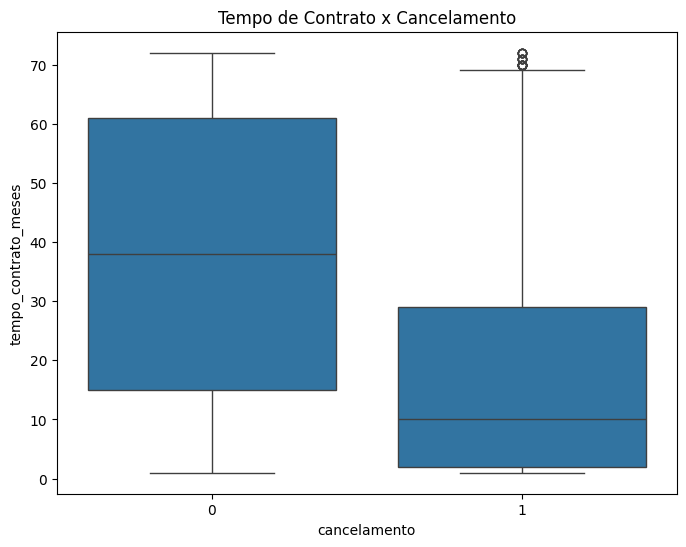

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cancelamento', y='tempo_contrato_meses', data=df)
plt.title('Tempo de Contrato x Cancelamento')
plt.show()

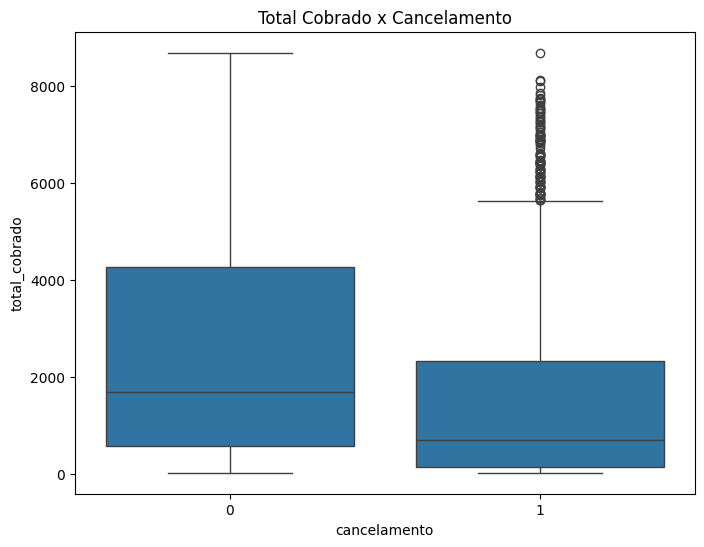

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cancelamento', y='total_cobrado', data=df)
plt.title('Total Cobrado x Cancelamento')
plt.show()

##**Modelagem Preditiva.**

###**Separação de Dados.**

DividI o conjunto de dados em treino e teste para avaliar o desempenho do modelo. Uma divisão comum é 70% para treino e 30% para teste, ou 80/20, dependendo do tamanho da base de dados.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # importante para manter proporção de cancelamento
)

In [22]:
print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

print("\nProporção treino:")
print(y_treino.value_counts(normalize=True))

print("\nProporção teste:")
print(y_teste.value_counts(normalize=True))

Treino: (5625, 31)
Teste: (1407, 31)

Proporção treino:
cancelamento
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Proporção teste:
cancelamento
0    0.734186
1    0.265814
Name: proportion, dtype: float64


###**Criação de Modelos.**

Nesta etapa terei que criar pelo menos dois modelos diferentes para prever a evasão de clientes.

Um modelo pode exigir normalização, como Regressão Logística ou KNN.

O outro modelo pode não exigir normalização, como Árvore de Decisão ou Random Forest.

Ao final irei justificar a escolha de cada modelo e, se optar por normalizar os dados, explicarei a necessidade dessa etapa.

In [23]:
# Normalizar para os modelos que precisam.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

Modelo 01 - Regressão Logística.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_treino_scaled, y_treino)

log_pred = log_model.predict(X_teste_scaled)

print("Logística:", accuracy_score(y_teste, log_pred))

Logística: 0.8009950248756219


Modelo 02 - KNN.

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_treino_scaled, y_treino)

knn_pred = knn_model.predict(X_teste_scaled)

print("KNN:", accuracy_score(y_teste, knn_pred))

KNN: 0.7555081734186212


Modelo 03 - Árvore de Decisão.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_treino, y_treino)

tree_pred = tree_model.predict(X_teste)

print("Árvore:", accuracy_score(y_teste, tree_pred))

Árvore: 0.7228144989339019


Modelo 04 - Random Forest.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_treino, y_treino)

rf_pred = rf_model.predict(X_teste)
print("Random Forest:", accuracy_score(y_teste, rf_pred))

Random Forest: 0.7953091684434968


Resultado de todos.

In [28]:
print("Logística:", accuracy_score(y_teste, log_pred))
print("KNN:", accuracy_score(y_teste, knn_pred))
print("Árvore:", accuracy_score(y_teste, tree_pred))
print("Random Forest:", accuracy_score(y_teste, rf_pred))

Logística: 0.8009950248756219
KNN: 0.7555081734186212
Árvore: 0.7228144989339019
Random Forest: 0.7953091684434968


Justificativa

Nesta etapa escolhi os quatro modelos para comparar diferentes abordagens preditivas:

- Regressão Logística: modelo linear, simples e interpretável. Foi utilizado como baseline por ser eficiente em problemas binários como previsão de evasão.

- KNN: modelo baseado em distância, escolhido para avaliar como a proximidade entre clientes influencia a previsão de cancelamento. Exigiu normalização dos dados.

- Árvore de Decisão: modelo baseado em regras, capaz de capturar relações não lineares sem necessidade de normalização.

- Random Forest: conjunto de múltiplas árvores, utilizado para aumentar robustez e reduzir overfitting, permitindo capturar padrões mais complexos.

Modelos baseados em distância (Regressão Logística e KNN) exigiram padronização dos dados, enquanto modelos baseados em árvore (Decision Tree e Random Forest) não necessitam dessa etapa, pois não são sensíveis à escala das variáveis.

###**Avaliação dos Modelos.**

Nesta estapa avaliei cada modelo utilizando as seguintes métricas:

- Acurácia
- Precisão
- Recall
- F1-score
- Matriz de confusão

Em seguida, realizei uma análise crítica e comparei os modelos.

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Regressão Logística ===")
print(classification_report(y_teste, log_pred))
print(confusion_matrix(y_teste, log_pred))

print("\n=== KNN ===")
print(classification_report(y_teste, knn_pred))
print(confusion_matrix(y_teste, knn_pred))

print("\n=== Árvore de Decisão ===")
print(classification_report(y_teste, tree_pred))
print(confusion_matrix(y_teste, tree_pred))

print("\n=== Random Forest ===")
print(classification_report(y_teste, rf_pred))
print(confusion_matrix(y_teste, rf_pred))

=== Regressão Logística ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

[[929 104]
 [176 198]]

=== KNN ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1033
           1       0.54      0.50      0.52       374

    accuracy                           0.76      1407
   macro avg       0.68      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407

[[877 156]
 [188 186]]

=== Árvore de Decisão ===
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.48      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg  

Conclusão:

A Regressão Logística apresentou o melhor desempenho geral, especialmente na identificação de clientes que cancelaram (Recall = 0.53).

O Random Forest teve acurácia semelhante, mas apresentou recall inferior para a classe de evasão.

A Árvore de Decisão mostrou desempenho mais baixo, possivelmente devido a overfitting.

Considerando o objetivo de prever cancelamentos, a Regressão Logística se mostrou o modelo mais adequado.

##**Interpretação e Conclusões.**

###**Análise de Importância das Variáveis.**

Após escolher os modelos, realizei a análise das variáveis mais relevantes para a previsão de evasão:

In [30]:
# Regressão Logística - Coeficientes

import pandas as pd

coeficientes = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': log_model.coef_[0]
})

coeficientes.sort_values(by='Coeficiente', ascending=False)

,Variavel,Coeficiente
29,remainder__total_cobrado,0.614834
2,onehotencoder__tipo_internet_Fiber optic,0.409648
10,onehotencoder__tipo_contrato_Month-to-month,0.301951
25,remainder__streaming_tv,0.220025
27,remainder__fatura_digital,0.181270
4,onehotencoder__seguranca_online_No,0.161661
26,remainder__streaming_filmes,0.156869
22,remainder__multiplas_linhas,0.152875
15,onehotencoder__metodo_pagamento_Electronic check,0.127647
7,onehotencoder__backup_online_No,0.105198


In [31]:
# Random Forest - Importância das Variáveis

import pandas as pd

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf_model.feature_importances_
})

importancias.sort_values(by='Importancia', ascending=False)

,Variavel,Importancia
29,remainder__total_cobrado,0.151127
20,remainder__tempo_contrato_meses,0.134143
30,remainder__contas_diarias,0.126015
28,remainder__valor_mensal,0.123508
10,onehotencoder__tipo_contrato_Month-to-month,0.059308
24,remainder__suporte_tecnico,0.036411
4,onehotencoder__seguranca_online_No,0.030342
15,onehotencoder__metodo_pagamento_Electronic check,0.026586
0,onehotencoder__genero_Male,0.025230
2,onehotencoder__tipo_internet_Fiber optic,0.023714


###**Conclusão.**

Nesta etapa elaborei um relatório detalhado, destacando os fatores que mais influenciam a evasão, com base nas variáveis selecionadas e no desempenho de cada modelo.

Identifiquei os principais fatores que afetam a evasão de clientes e propus  estratégias de retenção com base nos resultados obtidos.

**Desempenho dos Modelos**

Entre os modelos avaliados, a Regressão Logística apresentou o melhor desempenho geral, considerando:

- Acurácia de aproximadamente 80%
- Melhor equilíbrio entre precisão e recall
- Melhor F1-score para a classe de cancelamento
- Maior interpretabilidade dos resultados

O Random Forest também apresentou bom desempenho, porém com recall inferior para a classe de cancelamento, o que é um ponto crítico quando o objetivo é prever evasão.

**Principais Fatores que Influenciam a Evasão.**

A análise dos coeficientes da Regressão Logística e da importância das variáveis no Random Forest mostrou que os principais fatores associados ao cancelamento são:

Fatores que aumentam a evasão:

- Contrato mensal (Month-to-month)
- Internet do tipo Fiber optic
- Pagamento via Electronic check
- Fatura digital
- Ausência de serviços como segurança online
- Alto valor total acumulado
- Baixo tempo de contrato

Fatores que reduzem a evasão:

- Maior tempo de permanência na empresa (principal fator)
- Contratos de dois anos
- Presença de suporte técnico
- Métodos automáticos de pagamento (cartão ou transferência)

O tempo de contrato foi a variável mais relevante no modelo, indicando que clientes novos possuem maior risco de cancelamento.

**Interpretação Estratégica.**

Os resultados indicam que a evasão está fortemente relacionada à ausência de fidelização contratual e ao baixo tempo de relacionamento com a empresa.

Clientes com contrato mensal possuem maior flexibilidade para cancelar, o que aumenta o risco de churn. Além disso, clientes nos primeiros meses de serviço ainda não consolidaram vínculo com a empresa, tornando-se mais sensíveis a insatisfações.

**Estratégias de Retenção Propostas.**

Com base nos resultados obtidos, recomenda-se:

01 - Incentivar contratos de longo prazo:
Oferecer descontos ou benefícios para migração de contrato mensal para contratos anuais ou bianuais.

02 - Foco nos primeiros meses do cliente:
Criar campanhas de acompanhamento nos primeiros 3–6 meses, período de maior risco.

03 - Incentivar métodos automáticos de pagamento:
Estimular pagamento via cartão ou débito automático para reduzir cancelamentos associados ao Electronic check.

04 - Oferecer suporte técnico como benefício estratégico:
Clientes com suporte técnico apresentam menor probabilidade de evasão.

05 - Monitoramento contínuo com modelo preditivo:
Utilizar a Regressão Logística como ferramenta operacional para identificar clientes com alto risco de churn e agir preventivamente.

 ...

**Conclusão Final.**

O projeto demonstrou que é possível prever a evasão de clientes com bom nível de precisão utilizando técnicas de Machine Learning.

A Regressão Logística mostrou-se o modelo mais adequado por combinar desempenho satisfatório e alta interpretabilidade, permitindo não apenas prever cancelamentos, mas também entender os fatores que influenciam essa decisão.

Os resultados obtidos fornecem direcionamentos claros para estratégias de retenção, permitindo que a empresa atue de forma preventiva e orientada por dados.

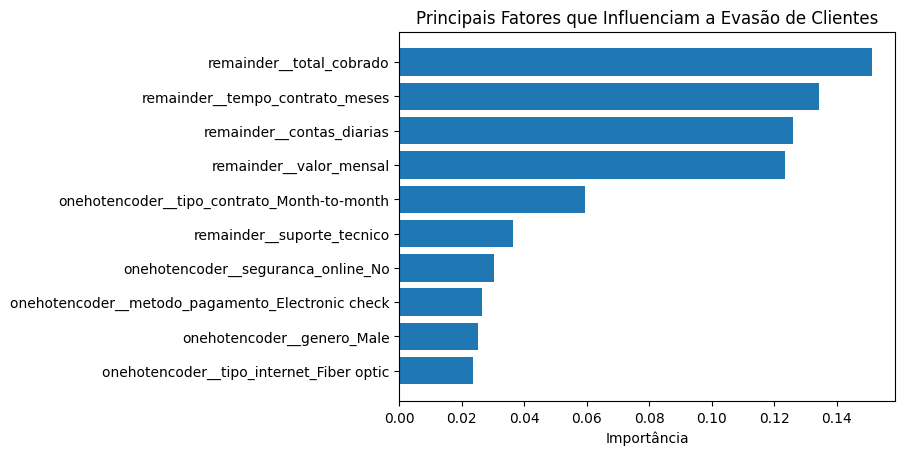

In [32]:
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

top10 = importancias.head(10)

plt.figure()
plt.barh(top10['Variavel'], top10['Importancia'])
plt.gca().invert_yaxis()
plt.title("Principais Fatores que Influenciam a Evasão de Clientes")
plt.xlabel("Importância")
plt.show()

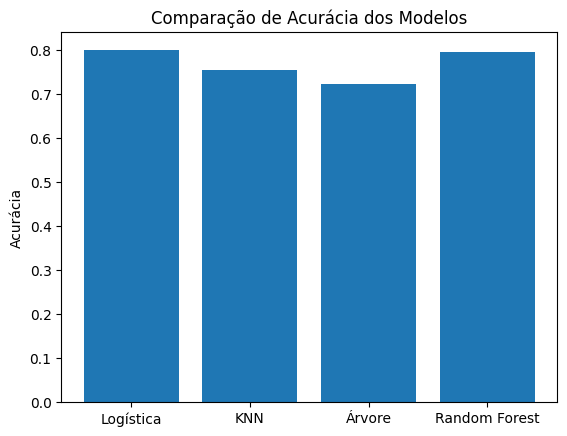

In [33]:
modelos = ['Logística', 'KNN', 'Árvore', 'Random Forest']
acuracias = [0.8009, 0.7555, 0.7228, 0.7953]

plt.figure()
plt.bar(modelos, acuracias)
plt.title("Comparação de Acurácia dos Modelos")
plt.ylabel("Acurácia")
plt.show()

In [34]:
# FINALIZADO.